In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Q1. Distance Matrix with NumPy Broadcasting
A = np.array([[1, 2],
 [4, 6],
 [7, 1]])
B = np.array([[0, 0],
 [5, 5]])
# 1. Reshape A and B for broadcasting: A_exp = A[:, np.newaxis, :] and B_exp = B[np.newaxis, :, :] . Print both shapes.
print("Original shape of A:", A.shape)
print("Original shape of B:", B.shape)
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :]
print("Shape of A_exp:", A_exp.shape)
print("Shape of B_exp:", B_exp.shape, "\n")

# 2. Compute the difference diff = A_exp - B_exp . Print its shape.
diff = A_exp - B_exp
print("Shape of diff:", diff.shape, "\n")
print("Difference matrix (A_exp - B_exp):")
print(diff, "\n")

# 3. Compute the Euclidean distance matrix using np.sqrt(np.sum(diff**2, axis=2)) . Print the result rounded to 2 decimal places.
distances = np.sqrt(np.sum(diff**2, axis=2))
print("Euclidean distance matrix:")
print(np.round(distances, 2))

# 4. In a Markdown cell, answer: which warehouse (B0 or B1) is closer on average to all delivery locations?
avg_b0 = np.mean(distances[:, 0])
avg_b1 = np.mean(distances[:, 1])
if(avg_b0 < avg_b1):
    print("\nWarehouse B0 is closer on average to all delivery locations.")
elif(avg_b1 < avg_b0):
    print("\nWarehouse B1 is closer on average to all delivery locations.")


Original shape of A: (3, 2)
Original shape of B: (2, 2)
Shape of A_exp: (3, 1, 2)
Shape of B_exp: (1, 2, 2) 

Shape of diff: (3, 2, 2) 

Difference matrix (A_exp - B_exp):
[[[ 1  2]
  [-4 -3]]

 [[ 4  6]
  [-1  1]]

 [[ 7  1]
  [ 2 -4]]] 

Euclidean distance matrix:
[[2.24 5.  ]
 [7.21 1.41]
 [7.07 4.47]]

Warehouse B1 is closer on average to all delivery locations.


The average distance from all delivery locations to **B0** is **5.51**.

The average distance from all delivery locations to **B1** is **3.63**.

Since **3.63 < 5.51**, **warehouse B1 is closer on average** to all delivery locations.

In [4]:
# Q2. Given:
p = [2, 1, -3]
q = [4, -2, 1]

# 1. Compute p · q using four different methods (loop, np.dot , np.multiply + sum , np.matmul ).
dot_product_loop = 0
for i in range(len(p)):
    dot_product_loop += p[i] * q[i]
print("Dot product using loop:", dot_product_loop, "\n")

dot_product_np_dot = np.dot(p, q)
print("Dot product using np.dot:", dot_product_np_dot, "\n")

dot_product_multiply_sum = np.sum(np.multiply(p, q))
print("Dot product using np.multiply + sum:", dot_product_multiply_sum, "\n")

dot_product_matmul = np.matmul(p, q)
print("Dot product using np.matmul:", dot_product_matmul, "\n")

# 2. Using the geometric formula p · q = ||p|| × ||q|| × cos(θ) , compute the angle θ between p and q in both radians and degrees
dot_product = np.dot(p, q)
module_p = np.linalg.norm(p)
module_q = np.linalg.norm(q)
cos = dot_product / (module_p * module_q)

radians = np.arccos(cos)
degrees = np.degrees(radians)

p_q = module_p * module_q * cos

print("p * q:", p_q)
print("Angle in radians:", radians)
print("Angle in degrees:", degrees, "\n")

# 3. Interpret the angle: are the vectors more aligned, perpendicular, or opposing?
# Angle between p and q is approximately 90 degrees, which indicates that the vectors are perpendicular to each other.

# 4. Now create a vector r that is guaranteed to be orthogonal to p (dot product = 0) in 3D. Verify it numerically.
r = [1, 1, 1]
dot_product_pr = np.dot(p, r)
print("Dot product of p and r:", dot_product_pr)

Dot product using loop: 3 

Dot product using np.dot: 3 

Dot product using np.multiply + sum: 3 

Dot product using np.matmul: 3 

p * q: 3.0
Angle in radians: 1.3949275767021716
Angle in degrees: 79.92346287144585 

Dot product of p and r: 0


Magnitude of u: 5.0
Magnitude of v: 10.0
Ratio ||v|| / ||u||: 2.0 

Unit vector of u: [ 0.6 -0.8]
Unit vector of v: [-0.6  0.8] 

Dot product of u and v: -50
u and v are parallel but in opposite directions.


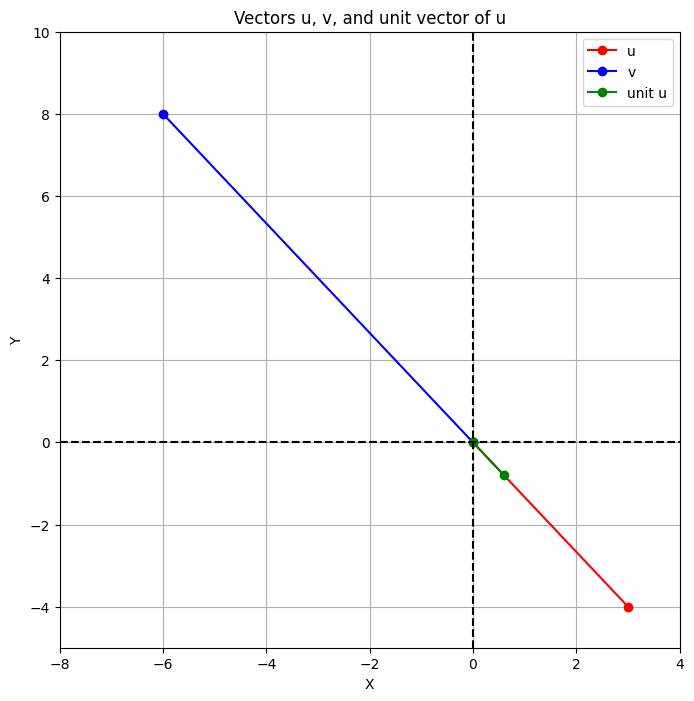

In [5]:
# Q3. Given vectors:
u = [3, -4]
v = [-6, 8]

# 1. Compute the magnitudes of u and v . What is the ratio ||v|| / ||u|| ? What does this ratio tell you?
magnitude_u = np.linalg.norm(u)
magnitude_v = np.linalg.norm(v)
ratio = magnitude_v / magnitude_u
print("Magnitude of u:", magnitude_u)
print("Magnitude of v:", magnitude_v)
print("Ratio ||v|| / ||u||:", ratio, "\n")
# v is twice as long as u and points in the opposite direction.

# 2. Compute the unit vectors of u and v . What do you notice?
unit_u = u / magnitude_u
unit_v = v / magnitude_v
print("Unit vector of u:", unit_u)
print("Unit vector of v:", unit_v, "\n")
# The unit vectors of u and v are the same but with opposite signs, indicating that u and v point in opposite directions.

# 3. Are u and v parallel? Justify your answer mathematically (do not just plot — use the dot product and magnitudes).
dot_product_uv = np.dot(u, v)
print("Dot product of u and v:", dot_product_uv)
if dot_product_uv == magnitude_u * magnitude_v:
    print("u and v are parallel.")
elif abs(dot_product_uv) == magnitude_u * magnitude_v:
    print("u and v are parallel but in opposite directions.")
else:
    print("u and v are not parallel.")
    
# Two vectors u and v are parallel if one is a scalar multiple of the other

# 4. On a single plot, draw u , v , and the unit vector of u . Add a legend and dashed axes.
plt.figure(figsize=(8, 8))
plt.plot([0, u[0]], [0, u[1]], 'r-o', label='u')          # u in red
plt.plot([0, v[0]], [0, v[1]], 'b-o', label='v')          # v in blue
plt.plot([0, unit_u[0]], [0, unit_u[1]], 'g-o', label='unit u')  # unit u in green

plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

plt.xlim(-8, 4)
plt.ylim(-5, 10)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vectors u, v, and unit vector of u')
plt.legend()
plt.grid(True)


In [6]:
# Q4. Pandas: Load, Explore & Clean
df = sns.load_dataset('mpg')
# 1. Print the shape and display the first 5 rows.
print("Shape of the DataFrame:", df.shape)
print("First 5 rows of the DataFrame:")
print(df.head(), "\n")

# 2. Print the number of missing values per column. Which column has missing values?
missing_values = df.isnull().sum()
print("Number of missing values per column:")
print(missing_values, "\n")
print("The 'horsepower' column has missing values.")

Shape of the DataFrame: (398, 9)
First 5 rows of the DataFrame:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino   

Number of missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64 


In [7]:
# 3. Create df_clean by dropping rows with any missing values using .dropna() . Print the new shape.
df_clean = df.dropna()
print("Shape of df_clean after dropping rows with missing values:", df_clean.shape, "\n")
missing_values = df_clean.isnull().sum()
print("Number of missing values per column for new DataFrame:")
print(missing_values, "\n")

# 4. Print basic summary statistics using .describe() . What is the average mpg ?
summary_stats = df_clean.describe()
print("Summary statistics for df_clean:")
print(summary_stats, "\n")
average_mpg = summary_stats.loc['mean', 'mpg']
print("Average mpg:", average_mpg)

# miles per gallon. how many miles a vehicle can travel using one gallon of fuel. On average, the cars in this dataset can travel about 23.44 miles on 1 gallon of gas.

Shape of df_clean after dropping rows with missing values: (392, 9) 

Number of missing values per column for new DataFrame:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64 

Summary statistics for df_clean:
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       accelerat

In [8]:
# Q5. Filtering, Sorting & GroupBy
# 1. Filter cars with mpg > 30 (fuel-efficient cars). Print how many there are.
fuel_efficient_cars = df_clean[df_clean['mpg'] > 30]
print("Number of fuel-efficient cars (mpg > 30):", fuel_efficient_cars.shape[0], "\n")

# 2. Sort the dataset by mpg in descending order and display the top 5 most fuel-efficient cars — show only the columns name , mpg , cylinders , origin
top_fuel_efficient_cars = df_clean.sort_values(by='mpg', ascending=False).head(5)
print("Top 5 most fuel-efficient cars:")
print(top_fuel_efficient_cars[['name', 'mpg', 'cylinders', 'origin']], "\n")

# 3. Use GroupBy to find the average mpg per country of origin ( origin ). Print the result.
avg_mpg_by_origin = df_clean.groupby('origin')['mpg'].mean()
print("Average mpg per country of origin:")
print(avg_mpg_by_origin, "\n")

# 4. In one Markdown sentence, state which country produces the most fuel-efficient cars on average.

Number of fuel-efficient cars (mpg > 30): 83 

Top 5 most fuel-efficient cars:
                     name   mpg  cylinders  origin
322             mazda glc  46.6          4   japan
329   honda civic 1500 gl  44.6          4   japan
325  vw rabbit c (diesel)  44.3          4  europe
394             vw pickup  44.0          4  europe
326    vw dasher (diesel)  43.4          4  europe 

Average mpg per country of origin:
origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64 



## Japan produces the most fuel-efficient cars on average, with an average mpg of 30.45.

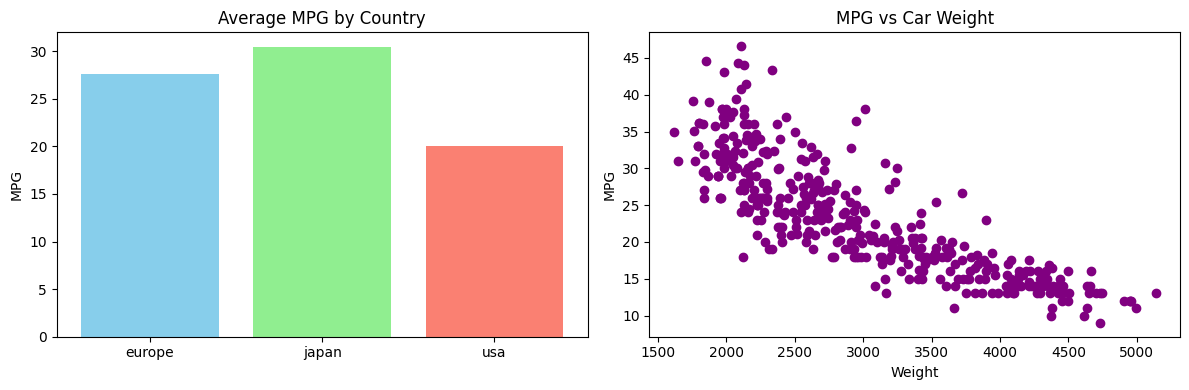

In [11]:
# Q6. Visualization
# Using df_clean , create a figure with two subplots side by side ( figsize=(12, 4) ):
# Left subplot: A bar plot of average mpg per origin . Title: 'Average MPG by Country' . Add a y-axis label 'MPG' .
# Right subplot: A scatter plot of weight (x-axis) vs mpg (y-axis). Title: 'MPG vs Car Weight' . Add axis labels.
# Use plt.tight_layout() and plt.show() . In a Markdown cell, write one observation from the scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(avg_mpg_by_origin.index, avg_mpg_by_origin.values, color=['skyblue', 'lightgreen', 'salmon'])
axes[0].set_title('Average MPG by Country')
axes[0].set_ylabel('MPG')

axes[1].scatter(df_clean['weight'], df_clean['mpg'], color='purple')
axes[1].set_title('MPG vs Car Weight')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('MPG')

plt.tight_layout() # Adjusts spacing between subplots so titles and labels don’t overlap.
plt.show()

## Heavier cars tend to have lower mpg, indicating that car weight negatively impacts fuel efficiency.

In [10]:
# Q7. KNN Classification on the Wine Dataset
# 1. Load the dataset and print feature_names , target_names , and the shape of the data
from sklearn.datasets import load_wine
wine = load_wine()
print("Feature names:", wine.feature_names)
print("Target names:", wine.target_names)
print("Shape of data:", wine.data.shape, "\n")

# 2. Split into train/test sets (75% train, 25% test) using random_state=42 .
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.25, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape, "\n")

# 3. Train a KNeighborsClassifier with n_neighbors=5 . Print the test accuracy.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print("Test accuracy of KNN classifier:", test_accuracy)

# 4. In a Markdown cell, state in one sentence whether this is a classification or regression problem and why.

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names: ['class_0' 'class_1' 'class_2']
Shape of data: (178, 13) 

Shape of X_train: (133, 13)
Shape of X_test: (45, 13)
Shape of y_train: (133,)
Shape of y_test: (45,) 

Test accuracy of KNN classifier: 0.7111111111111111


### This is a classification problem because the target variable (wine type) is discrete and has a limited number of possible values (3 classes).